

This notebook:
1. **Loads the saved `.pkl` model** (no retraining needed)
2. **Evaluates on the test dataset** (300 samples — 100 per class)
3. **Provides an interactive input cell** to manually test any sentence

**Classes:** `database_query` | `general_query` | `platform_query`

---
## 📦 Step 1 — Install Dependencies

In [1]:
# Run this only once. Restart runtime after if needed.
!pip install sentence-transformers scikit-learn pandas openpyxl seaborn matplotlib --quiet

---
## 📂 Step 2 — Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## ⚙️ Step 3 — Imports & Required Class/Function Definitions

> ⚠️ **Important:** The `.pkl` file uses `EmbeddingTransformer` and `generate_metadata`.  
> These **must be defined before** loading the model, otherwise `pickle.load` will fail.

In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)
from sentence_transformers import SentenceTransformer

print("✅ All imports successful.")

✅ All imports successful.


In [4]:
# ─────────────────────────────────────────────────────────
# MUST redefine these — they are part of the saved pipeline
# ─────────────────────────────────────────────────────────

class EmbeddingTransformer(BaseEstimator, TransformerMixin):
    """Wraps SentenceTransformer to fit into sklearn Pipeline."""
    def __init__(self, model_name="all-MiniLM-L6-v2"):
        self.model_name = model_name
        self.model = None

    def fit(self, X, y=None):
        self.model = SentenceTransformer(self.model_name)
        return self

    def transform(self, X):
        embeddings = self.model.encode(
            X.tolist(),
            show_progress_bar=False
        )
        return np.array(embeddings)


def generate_metadata(texts):
    """Generates text + 5 handcrafted metadata features for each sample."""
    lengths         = [len(t) for t in texts]
    word_counts     = [len(t.split()) for t in texts]
    avg_word_lengths = []
    uppercase_ratios = []
    digit_ratios     = []

    for t in texts:
        words = t.split()
        avg_word_lengths.append(np.mean([len(w) for w in words]) if words else 0)
        denom = max(len(t), 1)
        uppercase_ratios.append(sum(1 for c in t if c.isupper()) / denom)
        digit_ratios.append(sum(1 for c in t if c.isdigit()) / denom)

    return pd.DataFrame({
        "text"           : texts,
        "char_length"    : lengths,
        "word_count"     : word_counts,
        "avg_word_length": avg_word_lengths,
        "uppercase_ratio": uppercase_ratios,
        "digit_ratio"    : digit_ratios
    })


print("✅ EmbeddingTransformer and generate_metadata defined.")

✅ EmbeddingTransformer and generate_metadata defined.


---
## 🔁 Step 4 — Load the Saved `.pkl` Model

Update the path below to point to where you saved `25_march_svm_intent_classifier.pkl` in your Drive.

In [7]:
# ── UPDATE THIS PATH ──────────────────────────────────────────────────────────
MODEL_PATH = "/content/drive/MyDrive/final_intent_classifier/27_march_svm_intent_classifier.pkl"
# ─────────────────────────────────────────────────────────────────────────────

with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

print("✅ Model loaded successfully!")
print(f"   Model type : {type(model)}")
print(f"   Pipeline steps: {[s[0] for s in model.steps]}")

✅ Model loaded successfully!
   Model type : <class 'sklearn.pipeline.Pipeline'>
   Pipeline steps: ['features', 'clf']


In [8]:
# Class names (must match the order used during training — sorted alphabetically)
category_names = ['database_query', 'general_query', 'platform_query']
print("Classes:", category_names)

Classes: ['database_query', 'general_query', 'platform_query']


---
## 📊 Step 5 — Load Test Dataset & Run Evaluation

In [9]:
# ── UPDATE THIS PATH IF NEEDED ────────────────────────────────────────────────
TEST_PATH = "/content/drive/MyDrive/final_intent_classifier/test_dataset_100_each (1).xlsx"  # <--- Please verify this path in your Google Drive
# ─────────────────────────────────────────────────────────────────────────────

# Load from the combined sheet (300 samples)
test_df = pd.read_excel(TEST_PATH, sheet_name="All Test Queries (300)")
test_df = test_df[["Question", "Intent Label"]].dropna().reset_index(drop=True)

print(f"✅ Test dataset loaded: {len(test_df)} samples")
print("\nClass distribution:")
print(test_df["Intent Label"].value_counts())
test_df.head()

✅ Test dataset loaded: 300 samples

Class distribution:
Intent Label
general_query     100
database_query    100
platform_query    100
Name: count, dtype: int64


,Question,Intent Label
0,Who invented the airplane?,general_query
1,What is gravity?,general_query
2,Who invented electricity?,general_query
3,Who was Napoleon Bonaparte?,general_query
4,What is the greenhouse effect?,general_query


In [10]:
# Encode string labels → integers (same mapping as training)
label2idx = {lbl: i for i, lbl in enumerate(category_names)}
idx2label = {i: lbl for lbl, i in label2idx.items()}

X_test_texts = test_df["Question"].tolist()
y_test        = test_df["Intent Label"].map(label2idx).tolist()

print("Label mapping:", label2idx)
print(f"X_test size: {len(X_test_texts)}")

Label mapping: {'database_query': 0, 'general_query': 1, 'platform_query': 2}
X_test size: 300


In [11]:
# Generate feature DataFrame and run predictions
print("⏳ Generating features and running predictions...")
X_test_df = generate_metadata(X_test_texts)
y_pred    = model.predict(X_test_df)
print("✅ Predictions complete!")

⏳ Generating features and running predictions...
✅ Predictions complete!


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


### 📋 Classification Report

In [12]:
acc = accuracy_score(y_test, y_pred)
print(f"\n{'='*60}")
print(f"  Overall Accuracy : {acc * 100:.2f}%")
print(f"{'='*60}\n")
print(classification_report(y_test, y_pred, target_names=category_names))


  Overall Accuracy : 100.00%

                precision    recall  f1-score   support

database_query       1.00      1.00      1.00       100
 general_query       1.00      1.00      1.00       100
platform_query       1.00      1.00      1.00       100

      accuracy                           1.00       300
     macro avg       1.00      1.00      1.00       300
  weighted avg       1.00      1.00      1.00       300



### 🟦 Confusion Matrix

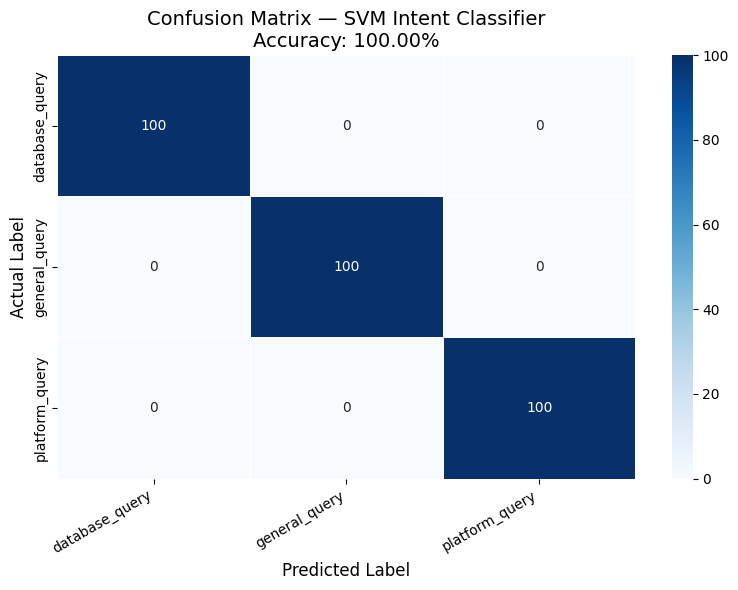

📁 Confusion matrix saved as 'confusion_matrix.png'


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=category_names,
    yticklabels=category_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — SVM Intent Classifier\nAccuracy: {acc*100:.2f}%', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("📁 Confusion matrix saved as 'confusion_matrix.png'")

### ❌ Misclassified Samples (for analysis)

In [14]:
results_df = test_df.copy()
results_df["Predicted"] = [category_names[p] for p in y_pred]
results_df["Correct"]   = results_df["Intent Label"] == results_df["Predicted"]

wrong_df = results_df[~results_df["Correct"]].reset_index(drop=True)

print(f"Total misclassified: {len(wrong_df)} / {len(results_df)}")
if len(wrong_df) > 0:
    print()
    display(wrong_df[["Question", "Intent Label", "Predicted"]])
else:
    print("🎉 Perfect score — no misclassifications!")

Total misclassified: 0 / 300
🎉 Perfect score — no misclassifications!


---
## 🎮 Step 6 — Interactive Input Tester

Run the cell below to enter any sentence and instantly see what the model predicts.  
Type **`quit`** to stop.

> 💡 **Try these examples:**
> - `What crops are available in the database?` → should predict `database_query`
> - `How do I reset my password?` → should predict `platform_query`
> - `What is the speed of light?` → should predict `general_query`

In [ ]:
def predict_single(text, mdl, cat_names):
    """Predict the intent for a single text input."""
    sample_df   = generate_metadata([text])
    pred_index  = mdl.predict(sample_df)[0]
    pred_label  = cat_names[pred_index]

    # Emoji map for nicer output
    emoji_map = {
        "database_query" : "🗄️  DATABASE QUERY",
        "platform_query" : "🖥️  PLATFORM QUERY",
        "general_query"  : "💬  GENERAL QUERY"
    }

    print(f"\n{'─'*60}")
    print(f"📝 Input     : {text[:120]}{'...' if len(text) > 120 else ''}")
    print(f"🏷️  Predicted : {emoji_map.get(pred_label, pred_label)}")
    print(f"{'─'*60}")


# ─── Interactive Loop ────────────────────────────────────────────────────────
print("=" * 60)
print("     SVM Intent Classifier — Interactive Tester")
print("=" * 60)
print(f"Categories : {category_names}")
print("Type 'quit' to exit.")
print()

while True:
    try:
        user_input = input("\n➤ Enter your query: ").strip()
    except EOFError:
        print("\n[Non-interactive environment detected — use predict_single() directly]")
        break

    if user_input.lower() == "quit":
        print("\n👋 Exiting interactive tester. Bye!")
        break
    if user_input == "":
        print("⚠️  Please enter some text.")
        continue

    predict_single(user_input, model, category_names)

     SVM Intent Classifier — Interactive Tester
Categories : ['database_query', 'general_query', 'platform_query']
Type 'quit' to exit.


➤ Enter your query: What is training feature set ?


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



────────────────────────────────────────────────────────────
📝 Input     : What is training feature set ?
🏷️  Predicted : 🖥️  PLATFORM QUERY
────────────────────────────────────────────────────────────

➤ Enter your query: How long does my login session remain active?


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



────────────────────────────────────────────────────────────
📝 Input     : How long does my login session remain active?
🏷️  Predicted : 🖥️  PLATFORM QUERY
────────────────────────────────────────────────────────────

➤ Enter your query: How many crops were added in the last 6 months?


...


────────────────────────────────────────────────────────────
📝 Input     : Who invented the airplane?
🏷️  Predicted : 💬  GENERAL QUERY
────────────────────────────────────────────────────────────

➤ Enter your query: "Show me the yield data for wheat in Punjab.",


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



────────────────────────────────────────────────────────────
📝 Input     : "Show me the yield data for wheat in Punjab.",
🏷️  Predicted : 🗄️  DATABASE QUERY
────────────────────────────────────────────────────────────

➤ Enter your query: "What are all the crops available in the database?"


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



────────────────────────────────────────────────────────────
📝 Input     : "What are all the crops available in the database?"
🏷️  Predicted : 🗄️  DATABASE QUERY
────────────────────────────────────────────────────────────


---
## 🔬 Step 7 — Batch Test Your Own Sentences (Optional)

Add sentences to the list below and run the cell to see predictions for all of them at once.

In [ ]:
# ── ADD YOUR OWN SENTENCES HERE ───────────────────────────────────────────────
custom_sentences = [
    "What are all the crops available in the database?",
    "I forgot my password, how can I reset it?",
    "What is the speed of light?",
    "Show me the yield data for wheat in Punjab.",
    "How do I navigate to the dashboard?",
    "Who invented the telephone?",
]
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  Batch Prediction — {len(custom_sentences)} sentences")
print(f"{'='*60}")

batch_df   = generate_metadata(custom_sentences)
batch_pred = model.predict(batch_df)

emoji_map = {
    "database_query": "🗄️ ",
    "platform_query": "🖥️ ",
    "general_query" : "💬 "
}

for text, pred_idx in zip(custom_sentences, batch_pred):
    label = category_names[pred_idx]
    print(f"\n  {emoji_map.get(label, '')} [{label}]")
    print(f"     → {text}")

print(f"\n{'='*60}")